<>:92: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:162: SyntaxWarning: invalid escape sequence '\l'
<>:185: SyntaxWarning: invalid escape sequence '\l'
<>:92: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:162: SyntaxWarning: invalid escape sequence '\l'
<>:185: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1752/1428999462.py:92: SyntaxWarning: invalid escape sequence '\l'
  f"Low ($\lambda=2$)\nBundle: {v_low['Bundle']:.2f}",
/tmp/ipykernel_1752/1428999462.py:127: SyntaxWarning: invalid escape sequence '\l'
  f"Medium ($\lambda=12$)\nBundle: {v_med['Bundle']:.2f}",
/tmp/ipykernel_1752/1428999462.py:162: SyntaxWarning: invalid escape sequence '\l'
  f"High ($\lambda=20$)\nBundle: {v_high['Bundle']:.2f}",
/tmp/ipykernel_1752/1428999462.py:185: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Waste Penalty Parameter ($\lambda$)', fontsize=10)


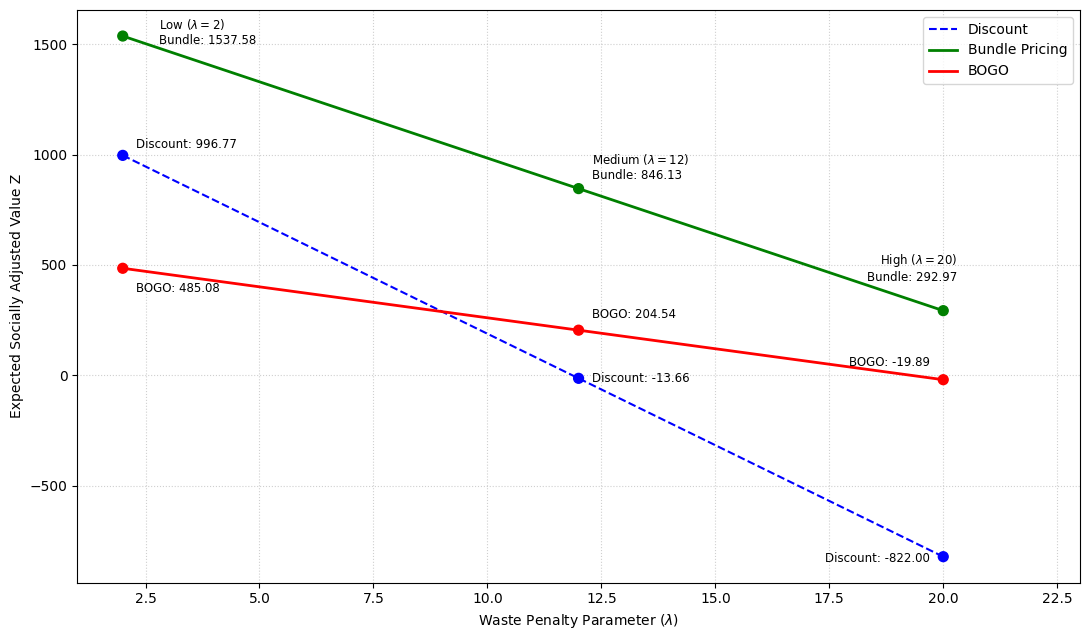

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



a, b, t, P, C, Cw, Q = 200, 1.0, 3, 100, 40, 2, 200
sigma = 20
delta_val = 2.0


P_dict = {'Discount': 95, 'Bundle': 75, 'BOGO': 50}
theta_dict = {'Discount': 0.00, 'Bundle': 0.10, 'BOGO': 0.20}

np.random.seed(42)
epsilon = np.random.normal(0, sigma, 10000)


def run_monte_carlo_lambda(lmbda_val):
  results = {}
  for strategy in ['Discount', 'Bundle', 'BOGO']:
    Ps = P_dict[strategy]
    theta = theta_dict[strategy]

    D0 = a - b * Ps - delta_val * t
    D_stochastic = np.maximum((1 + theta) * D0 + epsilon, 0)

    Y = np.minimum(Q, D_stochastic)
    W = Q - Y

    Z = Ps * Y - C * Q - (Cw + lmbda_val) * W
    results[strategy] = np.mean(Z)
  return results



lambda_range = np.linspace(2, 20, 100)
plot_data = {'lambda': [], 'Discount': [], 'Bundle': [], 'BOGO': []}

for l_val in lambda_range:
  res = run_monte_carlo_lambda(l_val)
  plot_data['lambda'].append(l_val)
  plot_data['Discount'].append(res['Discount'])
  plot_data['Bundle'].append(res['Bundle'])
  plot_data['BOGO'].append(res['BOGO'])

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(11, 6.5))
plt.plot(
    df_plot['lambda'],
    df_plot['Discount'],
    label='Discount',
    color='blue',
    linestyle='--',
)
plt.plot(
    df_plot['lambda'],
    df_plot['Bundle'],
    label='Bundle Pricing',
    color='green',
    linewidth=2,
)
plt.plot(
    df_plot['lambda'], df_plot['BOGO'], label='BOGO', color='red', linewidth=2
)

target_lambdas = [2.0, 12.0, 20.0]
snapshot_data = {}

for lmbda_target in target_lambdas:
  idx = (df_plot['lambda'] - lmbda_target).abs().idxmin()
  snapshot_data[lmbda_target] = {
      'Discount': df_plot.loc[idx, 'Discount'],
      'Bundle': df_plot.loc[idx, 'Bundle'],
      'BOGO': df_plot.loc[idx, 'BOGO'],
  }


l_low = 2.0
v_low = snapshot_data[l_low]
plt.scatter(
    [l_low, l_low, l_low],
    [v_low['Bundle'], v_low['Discount'], v_low['BOGO']],
    color=['green', 'blue', 'red'],
    s=50,
    zorder=5,
)
plt.text(
    l_low + 0.8,
    v_low['Bundle'] - 50,
    f"Low ($\lambda=2$)\nBundle: {v_low['Bundle']:.2f}",
    fontsize=8.5,
    ha='left',
    va='bottom',
)
plt.text(
    l_low + 0.3,
    v_low['Discount'] + 20,
    f"Discount: {v_low['Discount']:.2f}",
    fontsize=8.5,
    ha='left',
    va='bottom',
)
plt.text(
    l_low + 0.3,
    v_low['BOGO'] - 60,
    f"BOGO: {v_low['BOGO']:.2f}",
    fontsize=8.5,
    ha='left',
    va='top',
)


l_med = 12.0
v_med = snapshot_data[l_med]
plt.scatter(
    [l_med, l_med, l_med],
    [v_med['Bundle'], v_med['Discount'], v_med['BOGO']],
    color=['green', 'blue', 'red'],
    s=50,
    zorder=5,
)
plt.text(
    l_med + 0.3,
    v_med['Bundle'] + 30,
    f"Medium ($\lambda=12$)\nBundle: {v_med['Bundle']:.2f}",
    fontsize=8.5,
    ha='left',
    va='bottom',
)
plt.text(
    l_med + 0.3,
    v_med['BOGO'] + 40,
    f"BOGO: {v_med['BOGO']:.2f}",
    fontsize=8.5,
    ha='left',
    va='bottom',
)
plt.text(
    l_med + 0.3,
    v_med['Discount'] + 30,
    f"Discount: {v_med['Discount']:.2f}",
    fontsize=8.5,
    ha='left',
    va='top',
)


l_high = 20.0
v_high = snapshot_data[l_high]
plt.scatter(
    [l_high, l_high, l_high],
    [v_high['Bundle'], v_high['Discount'], v_high['BOGO']],
    color=['green', 'blue', 'red'],
    s=50,
    zorder=5,
)
plt.text(
    l_high + 0.3,
    v_high['Bundle'] + 120,
    f"High ($\lambda=20$)\nBundle: {v_high['Bundle']:.2f}",
    fontsize=8.5,
    ha='right',
    va='bottom',
)
plt.text(
    l_high - 0.3,
    v_high['BOGO'] + 50,
    f"BOGO: {v_high['BOGO']:.2f}",
    fontsize=8.5,
    ha='right',
    va='bottom',
)
plt.text(
    l_high - 0.3,
    v_high['Discount'] + 20,
    f"Discount: {v_high['Discount']:.2f}",
    fontsize=8.5,
    ha='right',
    va='top',
)


plt.xlabel('Waste Penalty Parameter ($\lambda$)', fontsize=10)
plt.ylabel('Expected Socially Adjusted Value Z', fontsize=10)
plt.xlim(1, 23)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()